# Exmaple 9: Flow time matrix

This Example demonstrates how create a matrix that calculates the flow times between all nodes in a network using dataframes provided by PT3S.

# PT3S Release

In [1]:
#pip install PT3S -U --no-deps

# Necessary packages for this Example

In [2]:
#pip install - q ...

# Imports

In [32]:
import os
import logging
import re
import pandas as pd
import numpy
import pandas as pd
from shapely.geometry import LineString
import matplotlib.pyplot as plt
from collections import deque
import networkx
from scipy.sparse import csc_matrix
#...

try:
    from PT3S import dxAndMxHelperFcts
except:
    import dxAndMxHelperFcts

try:
    from PT3S import Rm
except:
    import Rm
#...

In [33]:
import importlib

In [34]:
#importlib.reload(dxAndMxHelperFcts)

# Logging

In [35]:
logger = logging.getLogger()  

logFileName= r"Example9.log" 

loglevel = logging.DEBUG
logging.basicConfig(filename=logFileName
                        ,filemode='w'
                        ,level=loglevel
                        ,format="%(asctime)s ; %(name)-60s ; %(levelname)-7s ; %(message)s")    

fileHandler = logging.FileHandler(logFileName)     

logger.addHandler(fileHandler)

consoleHandler = logging.StreamHandler()
consoleHandler.setFormatter(logging.Formatter("%(levelname)-7s ; %(message)s"))
consoleHandler.setLevel(logging.INFO)
logger.addHandler(consoleHandler)

# Read Model and Results

In [36]:
dbFilename="Example5"
dbFile=os.path.join(os.path.dirname(os.path.abspath(dxAndMxHelperFcts.__file__))
                    +'/Examples/'
                    +dbFilename
                    +'.db3'
)

In [37]:
m=dxAndMxHelperFcts.readDxAndMx(dbFile=dbFile
                                ,preventPklDump=True
                                ,maxRecords=-1
                                )

INFO    ; Dx.__init__: dbFile (abspath): c:\users\aUserName\3s\pt3s\PT3S\Examples\Example5.db3 exists readable ...
INFO    ; Dx.__init__: dbFile (abspath): c:\users\aUserName\3s\pt3s\PT3S\Examples\Example5.db3 exists readable ...
INFO    ; PT3S.dxAndMxHelperFcts.readDxAndMx: 
+..\PT3S\Examples\Example5.db3 is newer than
+..\PT3S\Examples\WDExample5\B1\V0\BZ1\M-1-0-1.1.MX1:
+SIR 3S' dbFile is newer than SIR 3S' mx1File
+in this case the results are maybe dated or (worse) incompatible to the model
INFO    ; PT3S.dxAndMxHelperFcts.readDxAndMx: 
+..\PT3S\Examples\Example5.db3 is newer than
+..\PT3S\Examples\WDExample5\B1\V0\BZ1\M-1-0-1.1.MX1:
+SIR 3S' dbFile is newer than SIR 3S' mx1File
+in this case the results are maybe dated or (worse) incompatible to the model
INFO    ; Mx.setResultsToMxsFile: Mxs: ..\PT3S\Examples\WDExample5\B1\V0\BZ1\M-1-0-1.1.MXS reading ...
INFO    ; Mx.setResultsToMxsFile: Mxs: ..\PT3S\Examples\WDExample5\B1\V0\BZ1\M-1-0-1.1.MXS reading ...
INFO    ; dxWithMx.__i

In [38]:
#...

# Prepare data

## Get all edges

In [39]:
df_edges=m.V3_VBEL

In [40]:
df_edges=df_edges.reset_index()

In [41]:
df_edges=df_edges[['OBJID', 'OBJTYPE', 'tk_i', 'tk_k', 'NAME_i', 'NAME_k']]

In [42]:
df_edges=df_edges.rename(columns={'OBJID': 'tk', 'tk_i': 'tki', 'tk_k': 'tkk'})

In [43]:
df_edges.head(3)

,tk,OBJTYPE,tki,tkk,NAME_i,NAME_k
0,5175187672733343279,FWES,5203537039580738995,5416018875301313090,R-B1,V-B1
1,5237816858835684263,FWES,5386207966798159734,4904045401911412301,R-A1x,V-A1x
2,4615167946623235098,FWVB,5748663417295233893,5076580037121965427,V-1172,R-1172


In [44]:
print(df_edges['OBJTYPE'].unique())

['FWES' 'FWVB' 'KLAP' 'OBEH' 'PGRP' 'PUMP' 'REGV' 'ROHR' 'VENT']


## Get all nodes

In [45]:
df_nodes=m.V3_KNOT

In [46]:
df_nodes=df_nodes[df_nodes['KVR']==1.0]

In [47]:
df_nodes.head(3)

,pk,fkDE,rk,tk,NAME,KTYP,XKOR,YKOR,ZKOR,QM_EIN,...,"(STAT, KNOT~*~*~*~PMIN_INST, 2024-01-09 23:00:00, 2024-01-09 23:00:00)","(STAT, KNOT~*~*~*~QM, 2024-01-09 23:00:00, 2024-01-09 23:00:00)","(STAT, KNOT~*~*~*~RHO, 2024-01-09 23:00:00, 2024-01-09 23:00:00)","(STAT, KNOT~*~*~*~T, 2024-01-09 23:00:00, 2024-01-09 23:00:00)","(STAT, KNOT~*~*~*~VOLD, 2024-01-09 23:00:00, 2024-01-09 23:00:00)",PH,QM,dPH,srcvector,T
0,4678355169005004036,5613149064237404433,4678355169005004036,4680103632661687203,V-3354,QKON,55176.323661,98780.494875,29.299999,0.0,...,9.574781,0.0,939.375854,125.030182,0.0,8.574781,0.0,3.116916,"[0, 100]",125.030182
1,5759822415014073091,5613149064237404433,5759822415014073091,5540855804579832866,V-1503,QKON,48826.419913,98285.548412,30.500000,0.0,...,9.352022,0.0,935.382263,129.797485,0.0,8.352022,0.0,2.917446,"[100, 0]",129.797485
3,5468959419408453250,5613149064237404433,5468959419408453250,5025567272877293202,V-3604,QKON,53007.627163,98806.657826,26.600000,0.0,...,9.856769,0.0,936.526306,128.467102,0.0,8.856769,0.0,3.175158,"[96, 4]",128.467102


## Determine length, velocity, flow time, geometry per edge

In [48]:
df_pipes=m.gdf_ROHR

In [49]:
vav_cols = [col for col in df_pipes.columns if re.search(r'VAV', str(col))]

In [50]:
print(vav_cols)

[('STAT', 'ROHR~*~*~*~VAV', Timestamp('2024-01-09 23:00:00'), Timestamp('2024-01-09 23:00:00')), 'VAVAbs']


In [51]:
v=vav_cols[0] # we use the signed value

In [52]:
df_edges = df_edges.merge(
    df_pipes[['tk', v, 'L', 'geometry']],
    on='tk',
    how='left',
)

In [53]:
df_edges = df_edges.rename(columns={v: "v"})

we assume dt=0.001 for non-pipe edges

In [54]:
DEFAULT_DT = 0.001

df_edges['dt'] = df_edges.apply(
    lambda row: row['L'] / row['v'] if pd.notnull(row['L']) and pd.notnull(row['v']) and row['v'] != 0 else DEFAULT_DT,
    axis=1
)


In [55]:
df_edges.head(3)

,tk,OBJTYPE,tki,tkk,NAME_i,NAME_k,v,L,geometry,dt
0,5175187672733343279,FWES,5203537039580738995,5416018875301313090,R-B1,V-B1,NaN,NaN,None,0.001
1,5237816858835684263,FWES,5386207966798159734,4904045401911412301,R-A1x,V-A1x,NaN,NaN,None,0.001
2,4615167946623235098,FWVB,5748663417295233893,5076580037121965427,V-1172,R-1172,NaN,NaN,None,0.001


# Travel Time Matrix

## Implementation

In [56]:
TMAX_DETECT = 1.0e12

In [57]:
def setup_graph(df_data_results_edges):
    """Setup graph from edges data and results.

    Parameters
    ----------
    df_data_results_edges: pandas.DataFrame
        Edges data and results.

    Returns
    -------
    G : networkx.Graph
        Graph.
    """

    # Nodes: index mapping (here via tk of nodes, alternatively via names of nodes)
    list_nodes_tk = sorted(list(set(list(df_data_results_edges["tki"]) + list(df_data_results_edges["tkk"]))))
    map_nodes_tk_ind = {list_nodes_tk[ii]: ii for ii in range(len(list_nodes_tk))}

    # Adapt DataFrame
    df_data_results_edges["indi"] = df_data_results_edges["tki"].apply(lambda x: map_nodes_tk_ind[x])
    df_data_results_edges["indk"] = df_data_results_edges["tkk"].apply(lambda x: map_nodes_tk_ind[x])

    df_data_results_edges["indi_new"] = df_data_results_edges[["indi", "indk"]].min(axis=1)
    df_data_results_edges["indk_new"] = df_data_results_edges[["indi", "indk"]].max(axis=1)
    df_data_results_edges["dt_new"] = numpy.sign(df_data_results_edges["indk"] - df_data_results_edges["indi"])*df_data_results_edges["dt"]

    # Setup graph
    G = networkx.Graph()
    for _, row in df_data_results_edges.iterrows():
        G.add_edge(
            row['indi_new'],  # Start node
            row['indk_new'],  # End node
            # Additional edge attributes
            dt=row['dt_new']
        )

    # Out
    return G, map_nodes_tk_ind

In [58]:
def bfs_observedNodes(G, source, tmax):
    """Breadth-first-search starting at source.

    Parameters
    ----------
    G : networkx.Graph
        Graph.
    source : int
        Source node.
    tmax : float
        Maximum travel time.
    """

    visited = set([source])
    neighbors = G.neighbors
    queue = deque([(source, neighbors(source))])

    dt_travel_sum = {source: 0.0}

    while queue:
        parent, children = queue[0]

        try:
            child = next(children)

            edge = (min(parent, child), max(parent, child))
            sign_dt = numpy.sign(child - parent)

            dt_travel = sign_dt*G[edge[0]][edge[1]]['dt']
            dt_travel_sum[child] = dt_travel_sum[parent] + numpy.abs(dt_travel)

            if ((child not in visited) and (dt_travel_sum[child] < tmax) and dt_travel < 0.0):
                yield parent, child
                visited.add(child)
                queue.append((child, neighbors(child)))

        except StopIteration:
            queue.popleft()

In [59]:
def setup_travelTimeMatrix(df_data_results_edges):
    """Setup travel time matrix from edges data and results.

    Parameters
    ----------
    df_data_results_edges: pandas.DataFrame
        Edges data and results.

    Returns
    -------
    TMat : numpy.ndarray
        Travel time matrix.
    map_nodes_tk_ind : dict
        Mapping nodes tk to index.
    """

    # Setup graph
    G, map_nodes_tk_ind = setup_graph(df_data_results_edges)

    # Find sets of observed nodes by bfs search and setup matrix V
    obsNodes = {}
    obsNodesL = {}

    travelTimesAccObsNodesDict = {}

    for iSens in G.nodes:

        bfs_edges = list(bfs_observedNodes(G, iSens, TMAX_DETECT))

        nodesSet = set()
        endNodeLDict = {}

        for (lli, llk) in bfs_edges:
            nodesSet.add(lli)
            nodesSet.add(llk)
            edgex = (min(lli, llk), max(lli, llk))
            endNodeLDict[llk] = G[edgex[0]][edgex[1]]['dt']

        if (len(nodesSet) > 0):
            obsNodes[iSens] = nodesSet - {iSens}
            obsNodesL[iSens] = endNodeLDict

        # Calculate travel time matrix data
        edgesListUse = []
        for edgex in bfs_edges:
            (ix, kx) = edgex
            ix_new, kx_new = min(ix, kx), max(ix, kx)
            weight = abs(G[ix_new][kx_new]['dt'])
            edgesListUse.append((ix_new, kx_new, weight))

        Gtrav = networkx.Graph()
        if (len(edgesListUse) > 0):
            Gtrav.add_weighted_edges_from(edgesListUse)
            travelTimesAccObsNodesDict[iSens] = networkx.single_source_dijkstra_path_length(
                Gtrav, source=iSens, cutoff=None, weight='weight')

    # Setup travel time matrix
    rowsTTrav = []
    columnsTTrav = []
    dataTTrav = []

    for iSens in obsNodes.keys():
        # travel time from node to sensor
        ttravs = travelTimesAccObsNodesDict[iSens]
        for iObserved in ttravs:
            rowsTTrav.append(iSens)
            columnsTTrav.append(iObserved)
            dataTTrav.append(ttravs[iObserved])

    TMatSparse = csc_matrix((dataTTrav, (rowsTTrav, columnsTTrav)), shape=(len(G.nodes), len(G.nodes)))

    # Trafo to dense matrices
    TMat = 1.0*TMatSparse.toarray()

    # Out
    return TMat, map_nodes_tk_ind

## Use

In [60]:
TMat, map_nodes_tk_ind = setup_travelTimeMatrix(df_edges)

This method can calculate shortest travel time between two nodes. It shows us from a choosen source node how long water takes to reach all other nodes in the network based on the the length of pipes and the calculated velocity of water inside them, we get the flow time per pipe (dt = L / v). We do not consider the amount of flow (QM = pi/4 * DN^2 *v) going through the pipes nor the source spectrum. 

If we want to determine how the water flows through differnt paths from one source to another destination node we encounter issues, as all paths that are not the shortest are negletected, even if their flow is higher then the shortest path (eg. due to DN difference). We also dont differentiate between water originating from different hot water sources (Fernwaermeeinspeiser). For this application I do not see the travel time matrix of use.

In [61]:
numpy.set_printoptions(linewidth=200)
TMat.round(1)

array([[    0. , 14778.2, 16027.8, ..., 22093.4,  1465.5,  5964.8],
       [15975.7,     0. , 11128.1, ..., 13145.8, 17441.2, 14289.8],
       [16297.5, 10200.3,     0. , ..., 17515.5, 17763. , 14611.6],
       ...,
       [    0. ,     0. ,     0. , ...,     0. ,     0. ,     0. ],
       [10794.8, 16212.1, 17461.7, ..., 23527.3,     0. ,  6438.7],
       [55182.7, 62482.6, 63732.2, ..., 69797.8, 55407.1,     0. ]])

# Plot

In [62]:
def plot_flow_time_from_source(source_tk, travel_time_matrix, map_nodes_tk_ind, df_nodes):
    # Reverse the mapping to get index -> tk
    map_ind_tk = {v: k for k, v in map_nodes_tk_ind.items()}

    # Filter df_nodes based on XKOR > 40000 and YKOR > 80000
    df_nodes_filtered = df_nodes[(df_nodes['XKOR'] > 40000) & (df_nodes['YKOR'] > 80000)]

    # Create a mapping from tk to coordinates
    tk_to_coords = df_nodes_filtered.set_index('tk')[['XKOR', 'YKOR']].to_dict('index')

    # Get source index
    if source_tk not in map_nodes_tk_ind:
        print(f"Source tk {source_tk} not found in mapping.")
        return

    source_index = map_nodes_tk_ind[source_tk]
    travel_times = travel_time_matrix[source_index]

    # Prepare lists for plotting
    x_nonzero, y_nonzero, c_nonzero = [], [], []
    x_zero, y_zero = [], []

    for idx, time in enumerate(travel_times):
        tk = map_ind_tk.get(idx)
        if tk in tk_to_coords:
            x, y = tk_to_coords[tk]['XKOR'], tk_to_coords[tk]['YKOR']
            if idx == source_index:
                continue  # skip source node
            if time == 0.0:
                x_zero.append(x)
                y_zero.append(y)
            else:
                x_nonzero.append(x)
                y_nonzero.append(y)
                c_nonzero.append(time)

    plt.figure(figsize=Rm.DINA3q)
    scatter = plt.scatter(x_nonzero, y_nonzero, c=c_nonzero, cmap='viridis', s=40, label='Travel Time > 0')
    plt.scatter(x_zero, y_zero, color='red', marker='x', s=25, label='Travel Time = 0')

    # Mark the source node
    if source_tk in tk_to_coords:
        x_src, y_src = tk_to_coords[source_tk]['XKOR'], tk_to_coords[source_tk]['YKOR']
        plt.scatter(x_src, y_src, color='red', marker='*', s=150, label='Source Node')

    plt.colorbar(scatter, label='Travel Time')
    plt.xlabel('XKOR')
    plt.ylabel('YKOR')
    plt.title(f'Travel Time from Source Node {source_tk}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [63]:
df_nodes.head(5)

,pk,fkDE,rk,tk,NAME,KTYP,XKOR,YKOR,ZKOR,QM_EIN,...,"(STAT, KNOT~*~*~*~PMIN_INST, 2024-01-09 23:00:00, 2024-01-09 23:00:00)","(STAT, KNOT~*~*~*~QM, 2024-01-09 23:00:00, 2024-01-09 23:00:00)","(STAT, KNOT~*~*~*~RHO, 2024-01-09 23:00:00, 2024-01-09 23:00:00)","(STAT, KNOT~*~*~*~T, 2024-01-09 23:00:00, 2024-01-09 23:00:00)","(STAT, KNOT~*~*~*~VOLD, 2024-01-09 23:00:00, 2024-01-09 23:00:00)",PH,QM,dPH,srcvector,T
0,4678355169005004036,5613149064237404433,4678355169005004036,4680103632661687203,V-3354,QKON,55176.323661,98780.494875,29.299999,0.0,...,9.574781,0.0,939.375854,125.030182,0.0,8.574781,0.0,3.116916,"[0, 100]",125.030182
1,5759822415014073091,5613149064237404433,5759822415014073091,5540855804579832866,V-1503,QKON,48826.419913,98285.548412,30.500000,0.0,...,9.352022,0.0,935.382263,129.797485,0.0,8.352022,0.0,2.917446,"[100, 0]",129.797485
3,5468959419408453250,5613149064237404433,5468959419408453250,5025567272877293202,V-3604,QKON,53007.627163,98806.657826,26.600000,0.0,...,9.856769,0.0,936.526306,128.467102,0.0,8.856769,0.0,3.175158,"[96, 4]",128.467102
4,5526072131156860534,5613149064237404433,5526072131156860534,4660263951317730783,V-IHAF1,QKON,47711.710479,98384.669793,27.600000,0.0,...,8.944877,0.0,938.919312,125.600891,0.0,7.944877,0.0,1.545254,"[100, 0]",125.600891
6,4775668378312608776,5613149064237404433,4775668378312608776,5294552132139044612,V-1723,QKON,48064.236585,97197.304005,33.200001,0.0,...,8.403908,0.0,936.008301,129.101837,0.0,7.403908,0.0,1.526738,"[98, 2]",129.101837


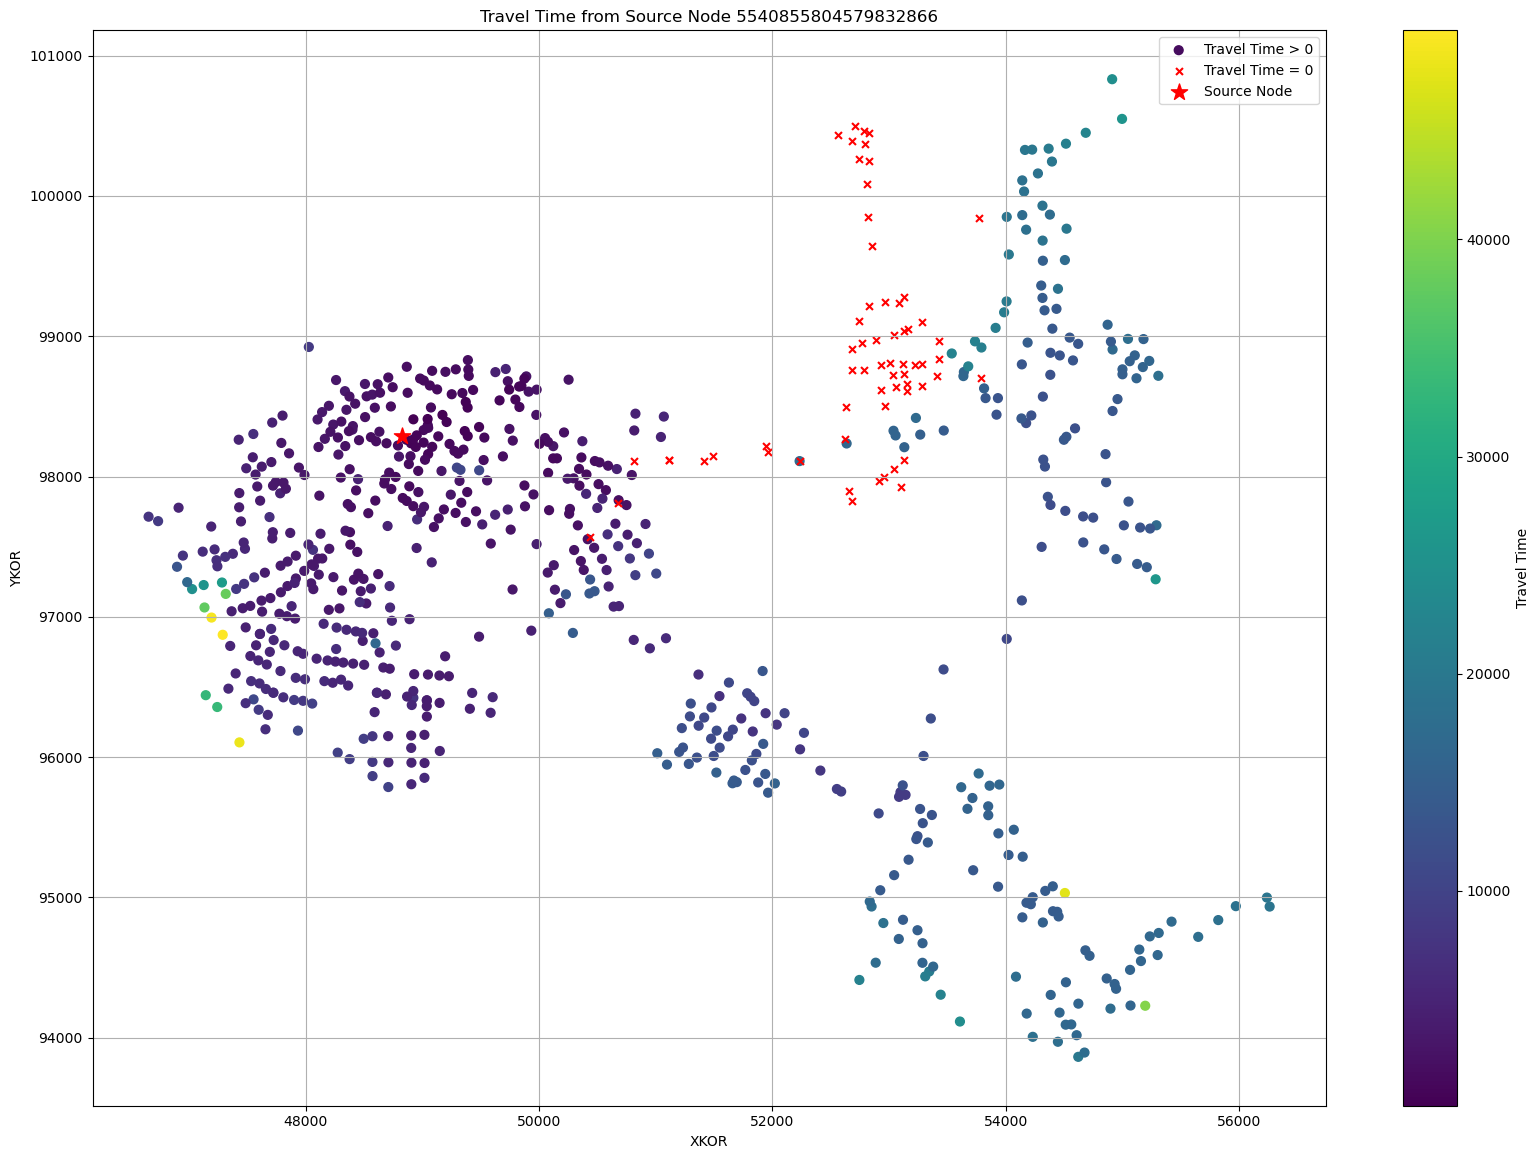

In [64]:
plot_flow_time_from_source("5540855804579832866", TMat, map_nodes_tk_ind, df_nodes)

## Plot from actual sources (Ferwaermeeinspeiser)

A: 5011622445515665493
B: 5152316559510921719

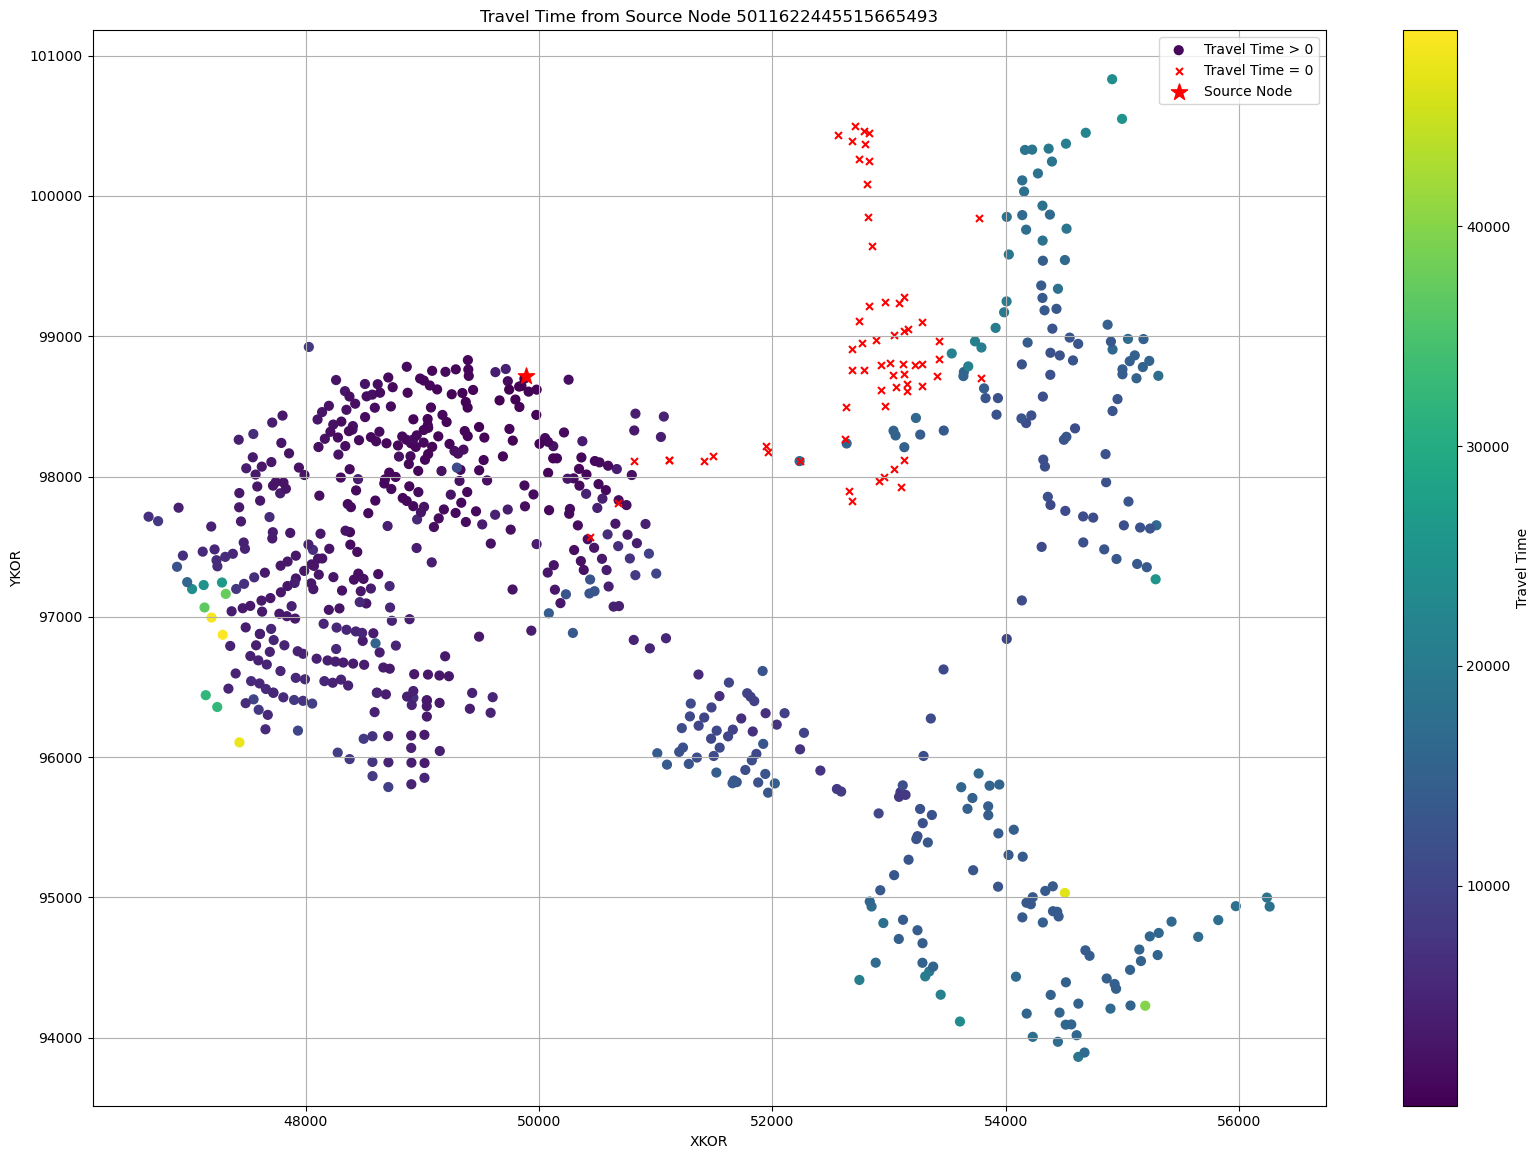

In [65]:
plot_flow_time_from_source("5011622445515665493", TMat, map_nodes_tk_ind, df_nodes)